## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import accuracy_score, confusion_matrix
pd.set_option('use_inf_as_na', True)
from collections import Counter

/tmp/ipykernel_1122050/2166773765.py:6: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('use_inf_as_na', True)


## Loading the Data Set (you need to put in the file where you have stored the data)

In [3]:
data = pd.read_parquet(r'data_small.parquet')

In [4]:
data.head()

acomincq      acoq       actq     altoq       ancq  \
date       ticker                                                       
2004-02-04 CSCO     432.000  2551.000  14961.000  1857.000  21629.000   
2004-02-10 BOBE       0.000    11.459     56.770    34.309    801.112   
2004-02-11 LZB        2.808    52.777    602.653    89.498    440.847   
           SCMR       1.736     4.389    652.139     2.536    358.745   
2004-02-12 BRCD       5.878    41.577    572.055   272.541    706.699   

                         aoq      apq        atq      capsq       ceqq  ...  \
date       ticker                                                       ...   
2004-02-04 CSCO    18188.000  645.000  36590.000  22295.000  27636.000  ...   
2004-02-10 BOBE       35.876   11.836    857.882    146.638    609.132  ...   
2004-02-11 LZB       239.449   69.475   1043.500    215.738    583.417  ...   
           SCMR      347.436    4.346   1010.884   1734.161    974.802  ...   
2004-02-12 BRCD      555.288   36.089   1278.754    731.074    668.392  ...   

                   SP_sector_code_700.0  SP_sector_code_800.0  \
date       ticker                                               
2004-02-04 CSCO                   False                 False   
2004-02-10 BOBE                   False                 False   
2004-02-11 LZB                    False                 False   
           SCMR                   False                 False   
2004-02-12 BRCD                   False                 False   

                   SP_sector_code_905.0  SP_sector_code_925.0  \
date       ticker                                               
2004-02-04 CSCO                   False                 False   
2004-02-10 BOBE                   False                 False   
2004-02-11 LZB                    False                 False   
           SCMR                   False                 False   
2004-02-12 BRCD                   False                 False   

                   SP_sector_code_935.0  SP_sector_code_940.0  \
date       ticker                                               
2004-02-04 CSCO                   False                  True   
2004-02-10 BOBE                   False                 False   
2004-02-11 LZB                    False                 False   
           SCMR                   False                  True   
2004-02-12 BRCD                   False                  True   

                   SP_sector_code_970.0  SP_sector_code_974.0  \
date       ticker                                               
2004-02-04 CSCO                   False                 False   
2004-02-10 BOBE                   False                 False   
2004-02-11 LZB                    False                 False   
           SCMR                   False                 False   
2004-02-12 BRCD                   False                 False   

                   SP_sector_code_976.0  SP_sector_code_978.0  
date       ticker                                              
2004-02-04 CSCO                   False                 False  
2004-02-10 BOBE                   False                  True  
2004-02-11 LZB                     True                 False  
           SCMR                   False                 False  
2004-02-12 BRCD                   False                 False  

[5 rows x 1237 columns]

In [5]:
data['spy_cum_ret']

date        ticker
2004-02-04  CSCO      0.014492
2004-02-10  BOBE      0.032131
2004-02-11  LZB       0.042754
            SCMR      0.042754
2004-02-12  BRCD      0.039136
                        ...   
2024-12-20  PAYX      2.434569
2024-12-23  CCL       2.440557
            WGO       2.440557
2024-12-27  MUFG      2.441212
2024-12-30  IMKTA     2.429800
Name: spy_cum_ret, Length: 141407, dtype: float64

## The Total Number of Companies w/ Market Cap > 1 Billion that appear during our time horizon

In [6]:
num_companies = len(data.index.get_level_values(1).unique())
num_companies

4606

## Filling in Missing Values

In [5]:
data = data.copy()
data.replace([np.inf,-np.inf],np.nan,inplace=True)
data = data.groupby('ticker').ffill()

In [6]:
data = data.fillna(0)

In [7]:
data['pred_rel_return']

date        ticker
2004-02-04  CSCO     -0.065311
2004-02-10  BOBE     -0.129205
2004-02-11  LZB      -0.143428
            SCMR     -0.137842
2004-02-12  BRCD     -0.134364
                        ...   
2024-12-20  PAYX      0.000000
2024-12-23  CCL       0.000000
            WGO       0.000000
2024-12-27  MUFG      0.000000
2024-12-30  IMKTA     0.000000
Name: pred_rel_return, Length: 141407, dtype: float64

#### We label a Data Point +1 if the difference between the return on the SPY and the return on the stock exceeds 5% during the earnings period, -1 if it is < -5% and 0 if it is between -5% and +5%. The function below turns the return differences into labels

In [8]:
def f(x):
    if x > 0.05:
        return 1
    elif x < -0.05:
        return -1
    else:
        return 0

#### Applying the function to the column of relative returns and making a column of labels

In [9]:
data = data.copy()
data['rel_performance'] = data['pred_rel_return'].apply(f)

In [10]:
data['next_period_return'].to_frame()

next_period_return
date       ticker                    
2004-02-04 CSCO             -0.081041
2004-02-10 BOBE             -0.123024
2004-02-11 LZB              -0.171157
           SCMR             -0.181834
2004-02-12 BRCD             -0.182212
...                               ...
2024-12-20 PAYX              0.000000
2024-12-23 CCL               0.000000
           WGO               0.000000
2024-12-27 MUFG              0.000000
2024-12-30 IMKTA             0.000000

[141407 rows x 1 columns]

#### This is the column of labels

In [11]:
data['rel_performance']

date        ticker
2004-02-04  CSCO     -1
2004-02-10  BOBE     -1
2004-02-11  LZB      -1
            SCMR     -1
2004-02-12  BRCD     -1
                     ..
2024-12-20  PAYX      0
2024-12-23  CCL       0
            WGO       0
2024-12-27  MUFG      0
2024-12-30  IMKTA     0
Name: rel_performance, Length: 141407, dtype: int64

### Make date the index, remember that the date is the first business day after Earnings Release

In [12]:
data.reset_index(inplace=True)
data.set_index('date',inplace=True)
data.sort_index(inplace=True)

### This what the data set looks like now

In [13]:
data

,ticker,acomincq,acoq,actq,altoq,ancq,aoq,apq,atq,capsq,...,SP_sector_code_800.0,SP_sector_code_905.0,SP_sector_code_925.0,SP_sector_code_935.0,SP_sector_code_940.0,SP_sector_code_970.0,SP_sector_code_974.0,SP_sector_code_976.0,SP_sector_code_978.0,rel_performance
date,,,,,,,,,,,,,,,,,,,,,
2004-02-04,CSCO,432.000,2551.000,14961.000,1857.000,21629.000,18188.000,645.000,36590.000,22295.000,...,False,False,False,False,True,False,False,False,False,-1
2004-02-10,BOBE,0.000,11.459,56.770,34.309,801.112,35.876,11.836,857.882,146.638,...,False,False,False,False,False,False,False,False,True,-1
2004-02-11,LZB,2.808,52.777,602.653,89.498,440.847,239.449,69.475,1043.500,215.738,...,False,False,False,False,False,False,False,True,False,-1
2004-02-11,SCMR,1.736,4.389,652.139,2.536,358.745,347.436,4.346,1010.884,1734.161,...,False,False,False,False,True,False,False,False,False,-1
2004-02-12,BRCD,5.878,41.577,572.055,272.541,706.699,555.288,36.089,1278.754,731.074,...,False,False,False,False,True,False,False,False,False,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-20,PAYX,-91.900,4246.900,7429.600,587.100,3125.100,2646.700,89.200,10554.700,1789.400,...,False,False,False,False,True,False,False,False,False,0
2024-12-23,CCL,-1975.000,1071.000,3378.000,591.000,45679.000,2517.000,1133.000,49057.000,17155.000,...,False,False,False,False,False,False,False,True,False,0
2024-12-23,WGO,-0.400,29.800,908.300,47.600,1389.700,1005.200,113.600,2298.000,194.300,...,False,False,False,False,False,False,False,True,False,0


### We use a training period of 5 years = 20 quarters

#### The validation set is the quarter starting 1 quarter after the end of the training period and the test set starting 1 quarter after the end of the validation period

In [14]:
df_train = data.loc['2004-01-01':'2009-01-01']
df_valid = data.loc['2009-04-01':'2009-07-01']
df_test = data.loc['2009-10-01':'2010-01-01']

In [352]:
df_train1 = data.loc['2009-01-01':'2014-01-01']
df_valid1 = data.loc['2014-04-01':'2014-07-01']
df_test1 = data.loc['2014-10-01':'2015-01-01']

#### Next we delete the columns that are not needed for training

In [353]:
train = df_train.reset_index().drop(['ticker','date',
                                   'next_period_return',
                                   'spy_next_period_return',
                                   'rel_performance','pred_rel_return',
                                  'return', 'cum_ret', 'spy_cum_ret'],axis=1)

valid = df_valid.reset_index().drop(['ticker','date',
                                   'next_period_return',
                                   'spy_next_period_return',
                                   'rel_performance','pred_rel_return',
                                  'return', 'cum_ret', 'spy_cum_ret',
                                    ],axis=1)
test = df_test.reset_index().drop(['ticker','date',
                                   'next_period_return',
                                   'spy_next_period_return',
                                   'rel_performance','pred_rel_return',
                                  'return', 'cum_ret', 'spy_cum_ret',
                            ],axis=1)

In [354]:
train1 = df_train1.reset_index().drop(['ticker','date',
                                   'next_period_return',
                                   'spy_next_period_return',
                                   'rel_performance','pred_rel_return',
                                  'return', 'cum_ret', 'spy_cum_ret'],axis=1)

valid1 = df_valid1.reset_index().drop(['ticker','date',
                                   'next_period_return',
                                   'spy_next_period_return',
                                   'rel_performance','pred_rel_return',
                                  'return', 'cum_ret', 'spy_cum_ret',
                                    ],axis=1)
test1 = df_test1.reset_index().drop(['ticker','date',
                                   'next_period_return',
                                   'spy_next_period_return',
                                   'rel_performance','pred_rel_return',
                                  'return', 'cum_ret', 'spy_cum_ret',
                            ],axis=1)

#### We take out the actual  earnings period stock returns in the training and test sets

In [355]:
train_stock_returns = df_train['next_period_return']
valid_stock_returns = df_valid['next_period_return']
test_stock_returns = df_test['next_period_return']

train1_stock_returns = df_train1['next_period_return']
valid1_stock_returns = df_valid1['next_period_return']
test1_stock_returns = df_test1['next_period_return']

In [356]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

In [357]:
scaler = MinMaxScaler()
float_vars = [x for x in train.columns if data[x].dtype == 'float64']
len(float_vars)

673

In [358]:
train = train.copy()
valid = valid.copy()
test = test.copy()

train1 = train1.copy()
valid1 = valid1.copy()
test1 = test1.copy()

train[float_vars] = scaler.fit_transform(train[float_vars])
valid[float_vars] = scaler.transform(valid[float_vars])
test[float_vars] = scaler.transform(test[float_vars])

scaler = MinMaxScaler()

train1[float_vars] = scaler.fit_transform(train1[float_vars])
valid1[float_vars] = scaler.transform(valid1[float_vars])
test1[float_vars] = scaler.transform(test1[float_vars])

In [ ]:
test['piy']

In [359]:
y_train = df_train['rel_performance'].values
y_valid = df_valid['rel_performance'].values
y_test = df_test['rel_performance'].values

y_train1 = df_train1['rel_performance'].values
y_valid1 = df_valid1['rel_performance'].values
y_test1 = df_test1['rel_performance'].values

## Number of Features

In [360]:
len(train.columns)

1231

## Importing the RandomForest Classifier and some metrics from sklearn

In [361]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

In [362]:
rf_clf = RandomForestClassifier(n_estimators=100,max_depth = 35,min_samples_leaf=50,
                                max_features='sqrt')
rf_clf1 = RandomForestClassifier(n_estimators=100,max_depth = 35,min_samples_leaf=50,
                                max_features='sqrt')
rf_clf.fit(train,y_train) 

rf_clf1.fit(train1,y_train1)

,n_estimators,100
,criterion,'gini'
,max_depth,35
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [363]:
accuracy_score(y_train,rf_clf.predict(train))

0.5578425929880002

In [364]:
accuracy_score(y_train1,rf_clf1.predict(train1))

0.5539007092198581

In [365]:
accuracy_score(y_valid,rf_clf.predict(valid))

0.39810924369747897

In [366]:
accuracy_score(y_valid1,rf_clf1.predict(valid1))

0.43811168681635004

## Now we are going to cut the features by looking at their importance in the tree. The visualization of the tree shows that only a few of the features are actually used

In [367]:
def random_forest_feat_importance(m, df):
    feature_importances = []
    for est in m.estimators_:
        fi = est.feature_importances_
        feature_importances.append(fi)
    feature_importances = np.array(feature_importances)
        
    return pd.DataFrame({'cols':train.columns, 'feat_imp':np.mean(feature_importances,axis=0)}
                       ).sort_values('feat_imp', ascending=False)


def plot_fi(fi): 
    fi.plot('cols', 'feat_imp', 'barh', figsize=(12,7), legend=False)
    plt.plot()

In [368]:
fi = random_forest_feat_importance(rf_clf,train)
fi
features = fi[(fi['feat_imp'] > 0.00)]
features

,cols,feat_imp
5,aoq,0.008455
11,chq,0.006811
601,dvq,0.006565
579,mkvaltq,0.006534
578,dvpsxq,0.006446
...,...,...
182,pncpepsq,0.000034
244,setaq,0.000034
233,rrd12,0.000033
295,udoltq,0.000026


In [369]:
fi = random_forest_feat_importance(rf_clf1,train1)
fi
features1 = fi[(fi['feat_imp'] > 0.00)]
features1

,cols,feat_imp
577,dvpspq,0.012814
578,dvpsxq,0.010014
582,prclq,0.009580
385,dvy,0.009024
649,fcf_yield,0.008757
...,...,...
320,wdpq,0.000033
117,invoq,0.000033
691,sector_code_147.0,0.000028
105,glpq,0.000024


## We are only going to use the features that have positive feature importance i.e. occur in the tree

### Feature importance spectrum

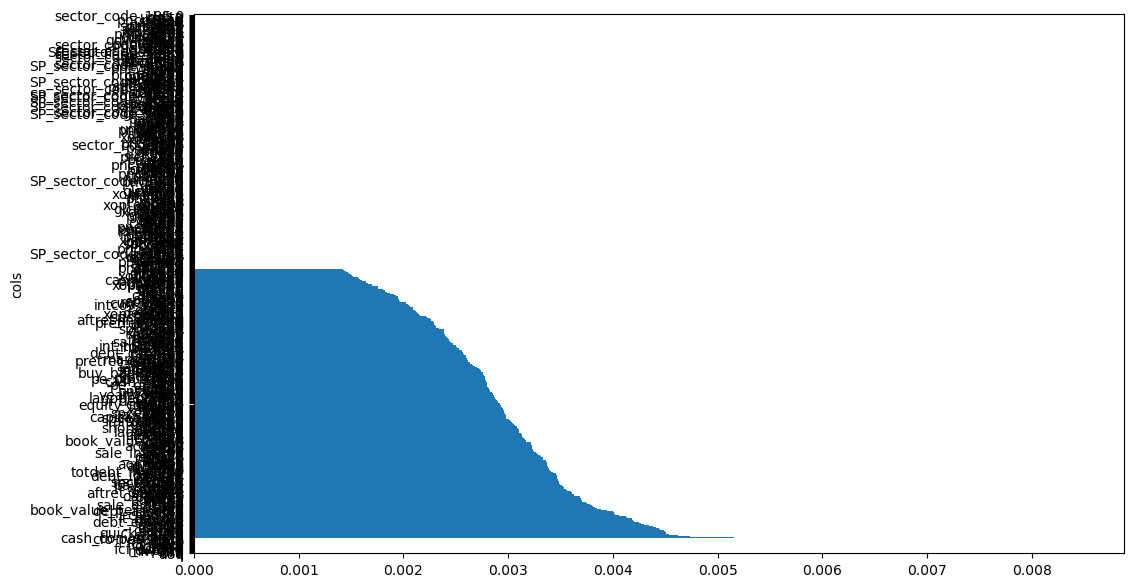

In [370]:
plot_fi(features);

In [371]:
cols = features['cols'].values
cols1 = features1['cols'].values

In [372]:
floats = [x for x in cols if data[x].dtype == 'float64']
floats1 = [x for x in cols1 if data[x].dtype == 'float64']

In [373]:
categorical = [x for x in cols if data[x].dtype == 'bool']
categorical1 = [x for x in cols if data[x].dtype == 'bool']

In [374]:
categorical

['SP_sector_code_935.0',
 'spcsrc_C',
 'SP_sector_code_976.0',
 'sic_1311',
 'sector_code_0.0',
 'SP_sector_code_940.0',
 'sector_code_705.0',
 'SP_sector_code_700.0',
 'sic_6020',
 'SP_sector_code_800.0',
 'SP_sector_code_978.0',
 'SP_sector_code_970.0',
 'sector_code_817.0',
 'spcsrc_B+',
 'SP_sector_code_905.0',
 'SP_sector_code_925.0',
 'sector_code_850.0',
 'spcsrc_B',
 'sic_6798',
 'sector_code_235.0',
 'spcsrc_A-',
 'sector_code_380.0',
 'SP_sector_code_0.0',
 'sector_code_175.0',
 'sector_code_835.0',
 'spcsrc_A',
 'sic_7372',
 'spcsrc_B-',
 'sector_code_185.0']

### We cut down the training and validation data sets to only include the relevant features and retrain the tree on the reduced data set

In [375]:
train_red = train[cols]
valid_red = valid[cols]
test_red = test[cols]

train_red1 = train1[cols1]
valid_red1 = valid1[cols1]
test_red1 = test1[cols1]

In [ ]:
scaler = MinMaxScaler()

In [376]:
train_red = train_red.copy()
valid_red = valid_red.copy()
test_red = test_red.copy()
train_red[floats] = scaler.fit_transform(train_red[floats])
valid_red[floats] = scaler.transform(valid_red[floats])
test_red[floats] = scaler.transform(test_red[floats])

scaler = MinMaxScaler()

train_red1 = train_red1.copy()
valid_red1 = valid_red1.copy()
test_red1 = test_red1.copy()
train_red1[floats1] = scaler.fit_transform(train_red1[floats1])
valid_red1[floats1] = scaler.transform(valid_red1[floats1])
test_red1[floats1] = scaler.transform(test_red1[floats1])

## Instantiating the classifier with hyper-parameters

In [377]:
import optuna
from optuna.trial import Trial
# optuna.logging.set_verbosity(optuna.logging.get_verbosity)
# import warnings
# warnings.filterwarnings("ignore")

In [378]:
def objective(trial:Trial,train=None,labels=None,val=None,val_labels=None,val_rets=None):

    t_min_samples_leaf = trial.suggest_int('min_samples_leaf',50,1200,step=50)
    t_max_depth = trial.suggest_int('max_depth',5,40,step=5)
    t_n_estimators = trial.suggest_int('n_estimators',5,50,step=5)
    t_max_features = trial.suggest_categorical('max_features',['sqrt','log2'])
    
    rf_clf = RandomForestClassifier(n_estimators=t_n_estimators,max_depth=t_max_depth,
                                    min_samples_leaf=t_min_samples_leaf,
                                    max_features=t_max_features,random_state=123,n_jobs=1)
    rf_clf.fit(train,labels)

    preds = rf_clf.predict(val)
    profit = (preds * val_rets).sum()

#     score = bg_clf.score(val,val_labels)

    return profit


In [379]:
study = optuna.create_study(direction="maximize")

[I 2026-01-28 17:00:21,735] A new study created in memory with name: no-name-0901239c-5758-4eb6-9e0c-bbf46f3a36ce


In [380]:
from functools import partial

In [381]:
%%time
study.optimize(partial(objective,train=train_red,labels=y_train,val=valid_red,val_labels=y_valid,val_rets=valid_stock_returns.values), n_trials=200,n_jobs=-1)

[I 2026-01-28 17:00:25,229] Trial 11 finished with value: 92.74582000000001 and parameters: {'min_samples_leaf': 900, 'max_depth': 5, 'n_estimators': 5, 'max_features': 'log2'}. Best is trial 11 with value: 92.74582000000001.
[I 2026-01-28 17:00:25,330] Trial 3 finished with value: 95.10742300000001 and parameters: {'min_samples_leaf': 800, 'max_depth': 35, 'n_estimators': 5, 'max_features': 'log2'}. Best is trial 3 with value: 95.10742300000001.
[I 2026-01-28 17:00:25,438] Trial 14 finished with value: 52.01089600000001 and parameters: {'min_samples_leaf': 100, 'max_depth': 35, 'n_estimators': 5, 'max_features': 'log2'}. Best is trial 3 with value: 95.10742300000001.
[I 2026-01-28 17:00:25,534] Trial 13 finished with value: 123.90152300000003 and parameters: {'min_samples_leaf': 750, 'max_depth': 25, 'n_estimators': 5, 'max_features': 'sqrt'}. Best is trial 13 with value: 123.90152300000003.
[I 2026-01-28 17:00:25,816] Trial 10 finished with value: 127.67651300000003 and parameters: {

CPU times: total: 5min 28s
Wall time: 37.8 s


In [382]:
study.best_params

{'min_samples_leaf': 1000,
 'max_depth': 35,
 'n_estimators': 50,
 'max_features': 'log2'}

In [383]:
study.best_value

130.321548

In [384]:
rf_clf = RandomForestClassifier(**study.best_params,random_state=123)

In [385]:
rf_clf.fit(train_red,y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,35
,min_samples_split,2
,min_samples_leaf,1000
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [386]:
accuracy_score(y_train,rf_clf.predict(train_red))

0.4110261775633087

In [387]:
accuracy_score(y_valid,rf_clf.predict(valid_red))

0.41491596638655465

In [388]:
study = optuna.create_study(direction="maximize")

[I 2026-01-28 17:01:29,218] A new study created in memory with name: no-name-fe6bbee0-7360-4a6d-9bf3-7da0831d4d0b


In [389]:
%%time
study.optimize(partial(objective,train=train_red1,labels=y_train1,val=valid_red1,val_labels=y_valid1,val_rets=valid1_stock_returns.values), n_trials=200,n_jobs=-1)

[I 2026-01-28 17:01:32,028] Trial 5 finished with value: 44.50624200000004 and parameters: {'min_samples_leaf': 1200, 'max_depth': 5, 'n_estimators': 5, 'max_features': 'sqrt'}. Best is trial 5 with value: 44.50624200000004.
[I 2026-01-28 17:01:32,078] Trial 0 finished with value: 45.82853200000007 and parameters: {'min_samples_leaf': 750, 'max_depth': 35, 'n_estimators': 10, 'max_features': 'log2'}. Best is trial 0 with value: 45.82853200000007.
[I 2026-01-28 17:01:32,244] Trial 14 finished with value: 42.137794000000035 and parameters: {'min_samples_leaf': 850, 'max_depth': 5, 'n_estimators': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 45.82853200000007.
[I 2026-01-28 17:01:32,602] Trial 10 finished with value: 44.09734100000006 and parameters: {'min_samples_leaf': 1000, 'max_depth': 20, 'n_estimators': 20, 'max_features': 'log2'}. Best is trial 0 with value: 45.82853200000007.
[I 2026-01-28 17:01:32,623] Trial 1 finished with value: 46.00883500000006 and parameters: {'mi

CPU times: total: 3min 24s
Wall time: 30 s


In [390]:
study.best_params

{'min_samples_leaf': 850,
 'max_depth': 20,
 'n_estimators': 10,
 'max_features': 'log2'}

In [391]:
study.best_value

47.65323200000006

In [392]:
rf_clf1 = RandomForestClassifier(**study.best_params,random_state=123)

In [393]:
rf_clf1.fit(train_red1,y_train1)

,n_estimators,10
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,850
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [394]:
def profit_importance(t,df,rets):
#     np.random.seed(123)
    profit = []
    for col in df.columns:
            X = df.copy()
            X[col] = np.random.permutation(df[col].values)
            prediction = t.predict(X)
            profit.append((prediction * rets).sum())
    return profit

In [395]:
def random_forest_profit_importance(m, df,rets):
    return pd.DataFrame({'cols':df.columns, 'pi_imp':profit_importance(m,df,rets)}
                       ).sort_values('pi_imp', ascending=True)

In [396]:
pi = random_forest_profit_importance(rf_clf,valid_red,df_valid['next_period_return'].values)
pi

,cols,pi_imp
15,cfo-per-share,128.330128
80,epsf12,128.846890
72,spceepspy,128.854444
11,fcf_yield,129.169955
100,evmq,129.208973
...,...,...
106,ibadjy,132.173936
23,epspiy,133.012483
162,dilavy,133.116502
18,piy,133.273011


In [397]:
pi1 = random_forest_profit_importance(rf_clf1,valid_red1,df_valid1['next_period_return'].values)
pi1

,cols,pi_imp
7,dvq,44.374522
146,intpny,45.940557
3,dvy,46.268832
75,at5,46.681719
132,aolochy,46.898152
...,...,...
27,epsf12,48.223754
17,sale_invcapq,48.318683
168,oepsxq,48.525970
53,ibmiiy,48.537073


In [398]:
profits = []
feat=[]

train = train_red.copy()
validation = valid_red.copy()

while len(train.columns)>1:

    col_to_drop = pi.iloc[-1]['cols']
    train.drop(col_to_drop,axis=1,inplace=True)
    validation.drop(col_to_drop,axis=1,inplace=True)
        
    rf_clf.fit(train,y_train)
    pi = random_forest_profit_importance(rf_clf,validation,df_valid['next_period_return'])

    pred_valid = rf_clf.predict(validation)
        
    print((pred_valid * df_valid['next_period_return']).sum())
    profits.append((pred_valid * df_valid['next_period_return']).sum())
    feat.append(train.columns)

132.141511
123.87967900000001
132.090123
132.06428499999998
122.015743
130.08953300000002
133.94144699999998
130.08919500000002
132.18188
129.38275399999998
119.848574
134.319511
135.820094
142.23761299999998
126.178661
130.563263
134.07576300000002
128.738967
136.06951600000002
130.53520300000002
137.34369199999998
142.570368
136.573977
134.745308
135.580693
136.31073
132.56451500000003
136.979583
131.217238
138.461061
140.66183800000002
132.24392899999998
140.723296
137.619346
137.491439
139.203011
141.586445
139.577101
144.667097
140.91578900000002
136.85199
142.204985
133.665595
140.687139
140.617728
138.28937000000002
139.09657199999998
136.762568
139.728499
137.896669
142.14059600000002
139.31745999999998
143.389569
141.664805
145.062971
137.134084
138.36343399999998
139.155643
142.852129
143.756188
144.24670600000002
142.189655
136.63183400000003
138.244667
141.89568500000001
139.27556299999998
141.34346299999999
145.2141
146.477013
145.718836
142.292939
141.149703
141.881024
14

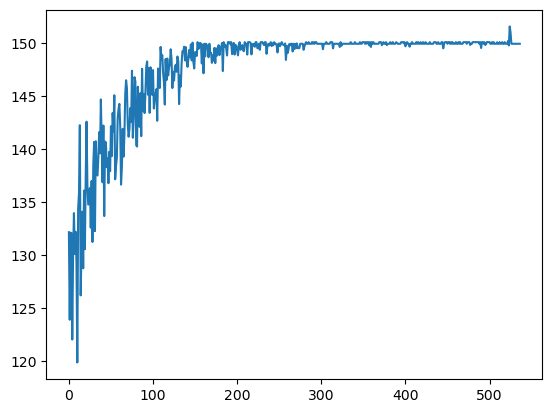

In [399]:
plt.plot(profits);

In [405]:
n = np.argmax(profits)
opt_feat = feat[524]

In [404]:
profits[524]

np.float64(151.55187500000002)

In [406]:
opt_feat

Index(['capsq', 'xopt12', 'pay_turnq', 'xoptqpy', 'xoptd12', 'pcfq', 'opmbdq',
       'xoptqp', 'recchy', 'invchy', 'exrey', 'cicurry', 'intcovq'],
      dtype='object')

In [407]:
np.max(profits)

np.float64(151.55187500000002)

In [408]:
profits1 = []
feat1=[]

train = train_red1.copy()
validation = valid_red1.copy()

while len(train.columns)>1:

    col_to_drop = pi1.iloc[-1]['cols']
    train.drop(col_to_drop,axis=1,inplace=True)
    validation.drop(col_to_drop,axis=1,inplace=True)
        
    rf_clf1.fit(train,y_train1)
    pi1 = random_forest_profit_importance(rf_clf1,validation,df_valid1['next_period_return'])

    pred_valid = rf_clf1.predict(validation)
        
    print((pred_valid * df_valid1['next_period_return']).sum())
    profits1.append((pred_valid * df_valid1['next_period_return']).sum())
    feat1.append(train.columns)

43.17315600000004
44.37967700000003
47.99487500000005
47.31033900000007
43.00246800000005
46.31347900000006
44.56158900000004
46.13521300000005
44.00199100000006
45.23447700000004
45.06265100000005
41.172870000000046
41.252261000000054
43.03217300000004
43.990301000000045
45.97065900000007
44.27898900000004
43.606273000000044
42.93940400000004
45.142417000000044
43.54792800000003
45.10168800000005
44.18618700000006
43.928147000000045
43.130920000000046
45.89416900000005
46.87428300000005
45.658918000000035
45.513084000000035
44.87282600000003
46.22314000000006
44.585721000000056
43.52412600000005
45.333903000000035
44.81513000000007
42.36810900000006
47.07415400000005
43.326296000000056
41.095749000000055
43.43639300000006
46.13791800000004
43.548363000000045
43.806346000000055
46.02807900000006
43.690112000000056
45.26216900000006
45.79345200000006
43.098044000000044
44.03339700000004
43.01979000000006
46.06275300000006
44.09376100000003
42.76364000000005
46.43034200000005
44.92388100

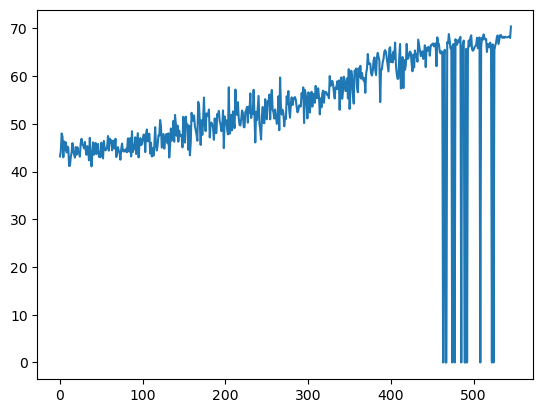

In [409]:
plt.plot(profits1)

In [410]:
n = np.argmax(profits1[:450])
opt_feat1 = feat1[n]

In [411]:
profits1[n]

np.float64(67.66987500000003)

In [412]:
opt_feat1

Index(['dpacreq', 'dpretq', 'retq', 'prcaq', 'dprety', 'pncepsy', 'cdvcy',
       'pnceps12', 'tieq', 'depcy',
       ...
       'rrpq', 'prcepsq', 'unopincq', 'sector_code_835.0', 'finxintq', 'spidy',
       'setpq', 'wdpq', 'sector_code_147.0', 'glpq'],
      dtype='object', length=113)

In [413]:
train_opt = train_red[opt_feat]
train_opt1 = train_red1[opt_feat1]

valid_opt = valid_red[opt_feat]
valid_opt1 = valid_red1[opt_feat1]

test_opt = test_red[opt_feat]
test_opt1 = test_red1[opt_feat1]

In [414]:
%%time
study = optuna.create_study(direction="maximize")

study.optimize(partial(objective,train=train_opt,labels=y_train,val=valid_opt,val_labels=y_valid,val_rets=valid_stock_returns.values), n_trials=200,n_jobs=-1)

[I 2026-01-28 18:09:39,836] A new study created in memory with name: no-name-8c6ed9d0-bb0e-443e-b056-6e33204cfcc6
[I 2026-01-28 18:09:40,226] Trial 0 finished with value: 145.29048900000004 and parameters: {'min_samples_leaf': 700, 'max_depth': 15, 'n_estimators': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 145.29048900000004.
[I 2026-01-28 18:09:40,254] Trial 5 finished with value: 124.32502000000001 and parameters: {'min_samples_leaf': 500, 'max_depth': 10, 'n_estimators': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 145.29048900000004.
[I 2026-01-28 18:09:40,497] Trial 6 finished with value: 149.763395 and parameters: {'min_samples_leaf': 1050, 'max_depth': 25, 'n_estimators': 15, 'max_features': 'log2'}. Best is trial 6 with value: 149.763395.
[I 2026-01-28 18:09:40,535] Trial 2 finished with value: 149.76850100000001 and parameters: {'min_samples_leaf': 1000, 'max_depth': 35, 'n_estimators': 15, 'max_features': 'sqrt'}. Best is trial 2 with value: 149.768501

CPU times: total: 1min 45s
Wall time: 18.2 s


In [418]:
study.best_value

151.897721

In [92]:
study.best_params

{'min_samples_leaf': 1150,
 'max_depth': 20,
 'n_estimators': 20,
 'max_features': 'log2'}

In [419]:
rf_clf = RandomForestClassifier(**study.best_params,random_state=123)

In [420]:
%%time
study = optuna.create_study(direction="maximize")

study.optimize(partial(objective,train=train_opt1,labels=y_train1,val=valid_opt1,val_labels=y_valid1,val_rets=valid1_stock_returns.values), n_trials=200,n_jobs=-1)

[I 2026-01-28 18:14:09,782] A new study created in memory with name: no-name-43178592-ebc3-4353-8355-7a0f199b7719
[I 2026-01-28 18:14:10,685] Trial 6 finished with value: 48.77710200000004 and parameters: {'min_samples_leaf': 300, 'max_depth': 30, 'n_estimators': 5, 'max_features': 'sqrt'}. Best is trial 6 with value: 48.77710200000004.
[I 2026-01-28 18:14:10,753] Trial 1 finished with value: 61.45431500000004 and parameters: {'min_samples_leaf': 650, 'max_depth': 40, 'n_estimators': 10, 'max_features': 'log2'}. Best is trial 1 with value: 61.45431500000004.
[I 2026-01-28 18:14:10,901] Trial 2 finished with value: 64.95494000000004 and parameters: {'min_samples_leaf': 1150, 'max_depth': 40, 'n_estimators': 15, 'max_features': 'sqrt'}. Best is trial 2 with value: 64.95494000000004.
[I 2026-01-28 18:14:10,925] Trial 3 finished with value: 65.55283200000002 and parameters: {'min_samples_leaf': 800, 'max_depth': 5, 'n_estimators': 15, 'max_features': 'log2'}. Best is trial 3 with value: 65

CPU times: total: 43.4 s
Wall time: 20.2 s


In [421]:
study.best_value

68.31806200000003

In [422]:
study.best_params

{'min_samples_leaf': 1000,
 'max_depth': 15,
 'n_estimators': 10,
 'max_features': 'log2'}

In [423]:
rf_clf1 = RandomForestClassifier(**study.best_params,random_state=123)

In [533]:
start_dates = [pd.to_datetime('2004-04-01') + pd.DateOffset(months = 3*i) for i in range(60)]
end_dates = [d + pd.DateOffset(months = 60) for d in start_dates]

In [534]:
training_frames = [data.loc[d:d+pd.DateOffset(months = 60)] for d in start_dates]
test_frames = [data.loc[d + pd.DateOffset(months=3):d+pd.DateOffset(months = 6)] for d in end_dates]

In [535]:
test_frames[19]

,ticker,acomincq,acoq,actq,altoq,ancq,aoq,apq,atq,capsq,...,SP_sector_code_800.0,SP_sector_code_905.0,SP_sector_code_925.0,SP_sector_code_935.0,SP_sector_code_940.0,SP_sector_code_970.0,SP_sector_code_974.0,SP_sector_code_976.0,SP_sector_code_978.0,rel_performance
date,,,,,,,,,,,,,,,,,,,,,
2014-04-01,CALM,0.365,2.170,439.909,4.799,357.168,50.640,72.266,797.077,40.043,...,False,False,False,False,False,False,False,False,True,1
2014-04-01,IOC,4.542,9.180,364.053,65.296,941.746,112.555,58.984,1305.799,26.418,...,False,False,False,False,False,False,False,False,False,-1
2014-04-01,UTIW,-143.317,163.354,1345.623,48.461,736.439,514.403,562.095,2082.062,0.000,...,False,False,False,False,False,False,False,False,False,-1
2014-04-01,VRNT,-39.725,72.296,694.391,43.652,1078.516,1038.371,65.656,1772.907,924.663,...,False,False,False,False,True,False,False,False,False,0
2014-04-02,APOL,-30.024,139.867,1427.081,110.757,1104.349,646.846,64.290,2531.430,0.000,...,False,False,False,False,False,False,False,True,False,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-06-27,WOR,-3.581,100.276,1198.922,22.399,1097.459,598.598,333.744,2296.381,262.610,...,False,False,False,False,False,True,False,False,False,-1
2014-06-30,AZZ,-8.025,27.184,329.929,176.459,653.610,456.194,52.986,983.539,23.581,...,False,False,True,False,False,False,False,False,False,-1
2014-06-30,CMC,1.814,169.340,2498.011,75.428,1120.458,188.714,392.706,3618.469,362.360,...,False,False,False,False,False,True,False,False,False,-1


In [536]:
training_data = [d.reset_index() for d in training_frames]
test_data = [d.reset_index() for d in test_frames]

In [537]:
training_labels = [d['rel_performance'].values for d in training_frames]

In [538]:
scalers = [MinMaxScaler() for _ in range(len(training_data))]
           
opt_training_data = [pd.DataFrame(scalers[i].fit_transform(training_frames[i][opt_feat].values),columns=opt_feat) for i in range(len(training_data))]
opt_test_data = [pd.DataFrame(scalers[i].transform(test_frames[i][opt_feat].values),columns=opt_feat) for i in range(len(test_data))]

In [539]:
x = [1]
ret = []

for i in range(len(start_dates)-1):
        rf_clf.fit(opt_training_data[i],training_labels[i])

        preds = rf_clf.predict(opt_test_data[i])
        profit_i = (preds*test_frames[i]['next_period_return']).sum()
        ret.append(profit_i)
        num_names = len(opt_test_data[i])
        x.append(x[i] + (x[i]/preds.sum())*profit_i)

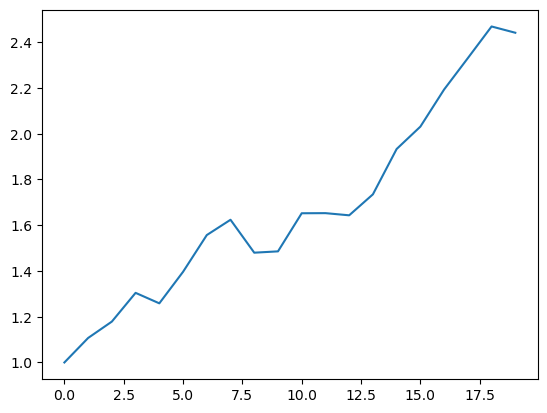

In [541]:
plt.plot(x[:20]);
plt.show()

In [437]:
x[19]

np.float64(2.441358837905423)

In [469]:
start_dates1 = [pd.to_datetime('2009-04-01') + pd.DateOffset(months = 3*i) for i in range(20)]
end_dates1 = [d + pd.DateOffset(months = 60) for d in start_dates1]

In [470]:
training_frames1 = [data.loc[d:d+pd.DateOffset(months = 60)] for d in start_dates1]
test_frames1 = [data.loc[d + pd.DateOffset(months=3):d+pd.DateOffset(months = 6)] for d in end_dates1]

In [475]:
test_frames1[-1]

,ticker,acomincq,acoq,actq,altoq,ancq,aoq,apq,atq,capsq,...,SP_sector_code_800.0,SP_sector_code_905.0,SP_sector_code_925.0,SP_sector_code_935.0,SP_sector_code_940.0,SP_sector_code_970.0,SP_sector_code_974.0,SP_sector_code_976.0,SP_sector_code_978.0,rel_performance
date,,,,,,,,,,,,,,,,,,,,,
2019-04-01,BB,-20.000,56.000,1194.000,45.000,2735.000,2650.000,48.000,3929.000,0.000,...,False,False,False,False,True,False,False,False,False,-1
2019-04-01,GLPG,-2.624,9.284,1521.398,5.075,126.678,100.189,77.897,1648.076,1462.927,...,False,False,False,False,False,False,False,False,False,-1
2019-04-01,KMX,-68.010,67.101,3214.013,221.609,15503.854,12675.796,593.171,18717.867,1237.153,...,False,False,False,False,False,False,False,True,False,1
2019-04-02,AMR,-23.130,57.163,829.601,311.245,1916.457,688.235,114.568,2746.058,761.301,...,False,False,False,False,False,False,False,False,False,-1
2019-04-02,CALM,0.039,3.912,617.404,5.629,577.051,137.751,84.116,1194.455,55.857,...,False,False,False,False,False,False,False,False,True,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-06-28,SJR,-79.000,176.000,2092.000,214.000,13375.000,8558.000,909.000,15467.000,25.000,...,False,False,False,False,False,False,False,False,True,0
2019-06-28,WAGE,-0.222,30.822,1111.950,34.605,554.249,455.776,26.911,1666.199,585.478,...,False,False,False,False,False,False,False,False,False,0
2019-06-28,WBA,-3393.000,870.000,19021.000,1133.000,49565.000,35848.000,14130.000,68586.000,10605.000,...,False,False,False,False,False,False,False,False,True,0


In [476]:
training_data1 = [d.reset_index() for d in training_frames1]
test_data1 = [d.reset_index() for d in test_frames1]

In [477]:
training_labels1 = [d['rel_performance'].values for d in training_frames1]

In [478]:
scalers = [MinMaxScaler() for _ in range(len(training_data1))]
           
opt_training_data1 = [pd.DataFrame(scalers[i].fit_transform(training_frames[i][opt_feat1].values),columns=opt_feat1) for i in range(len(training_data1))]
opt_test_data1 = [pd.DataFrame(scalers[i].transform(test_frames[i][opt_feat1].values),columns=opt_feat1) for i in range(len(test_data1))]

In [542]:
x1 = [x[19]]
ret = []

for i in range(len(start_dates1)-1):
        rf_clf1.fit(opt_training_data1[i],training_labels[i])

        preds = rf_clf1.predict(opt_test_data1[i])
        profit_i = (preds*test_frames[i]['next_period_return']).sum()
        ret.append(profit_i)
        num_names = len(opt_test_data1[i])
        x1.append(x1[i] + (x1[i]/preds.sum())*profit_i)

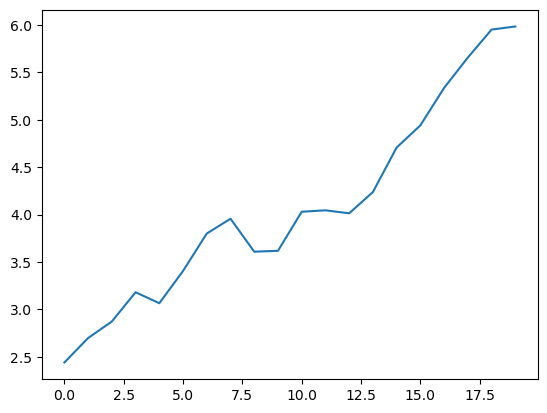

In [543]:
plt.plot(x1)

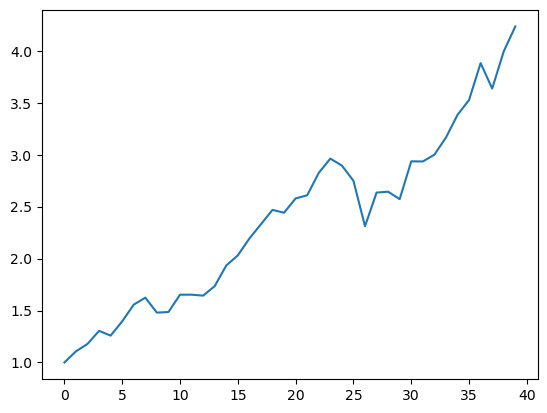

In [444]:
plt.plot(x)

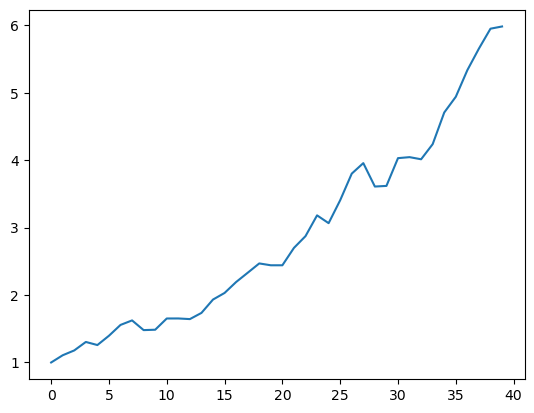

In [544]:
plt.plot(x[:20] + x1)

## Compared to a buy-and-hold of SPY

In [446]:
data_1 = pd.read_parquet(r'C:\Users\niels\OneDrive\Machine Learning 2026\Week 2\data_small.parquet')

In [447]:
SPY = data_1['spy_cum_ret'].to_frame()

In [448]:
SPY = SPY.reset_index()

In [449]:
SPY = SPY.drop(columns=['ticker'])

In [450]:
SPY = SPY.set_index(['date'])

In [451]:
SPY = SPY.drop_duplicates()

In [484]:
SPY.loc['2004-05-02':'2019-07-01'] - SPY['spy_cum_ret'].iloc[0] + 1

,spy_cum_ret
date,
2004-05-03,0.999239
2004-05-04,0.998436
2004-05-05,1.004861
2004-05-06,0.996260
2004-05-07,0.979714
...,...
2019-06-24,2.520082
2019-06-26,2.509277
2019-06-27,2.512823


In [485]:
SPY_res = SPY.loc['2009-07-02':'2019-05-31']
SPY_q = SPY_res.resample('QE').ffill()


In [486]:
len(SPY_q)

40

In [487]:
SPY_q['spy_cum_ret'] = (SPY_q['spy_cum_ret'] - SPY_q['spy_cum_ret'].iloc[0] + 1)
SPY_q['strategy'] = x[:20]+x1

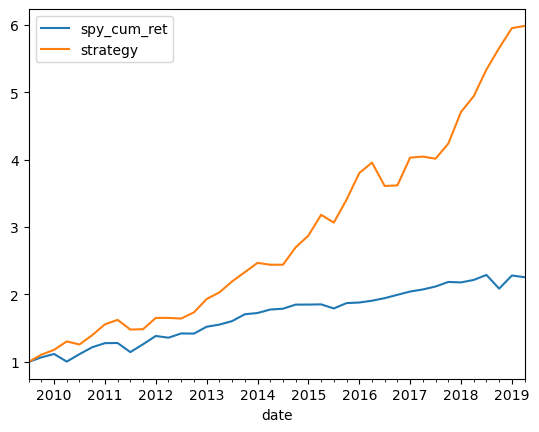

In [488]:
SPY_q.plot();
plt.show()

In [489]:
np.mean(SPY_q['strategy'].diff())/np.std(SPY_q['strategy'].diff())

np.float64(0.767263317377358)

In [490]:
SPY_y['strategy'].diff()

date
2009-12-31         NaN
2010-12-31    0.289327
2011-12-31    0.088847
2012-12-31    0.250544
2013-12-31    0.612336
2014-12-31    0.261697
2015-12-31    0.147358
2016-12-31    0.122495
2017-12-31    0.779242
2018-12-31    0.439526
2019-12-31    0.966109
2020-12-31    1.373574
2021-12-31    0.481341
2022-12-31    1.154408
2023-12-31    2.878185
2024-12-31    0.478943
Freq: YE-DEC, Name: strategy, dtype: float64

In [491]:
SPY_y = SPY_q.resample('YE').ffill()

In [492]:
SPY_y['spy_cum_ret'] = SPY_y['spy_cum_ret']-SPY_y['spy_cum_ret'].iloc[0]+1

In [493]:
SPY_y['strategy']=SPY_y['strategy'] - SPY_y['strategy'].iloc[0]+1

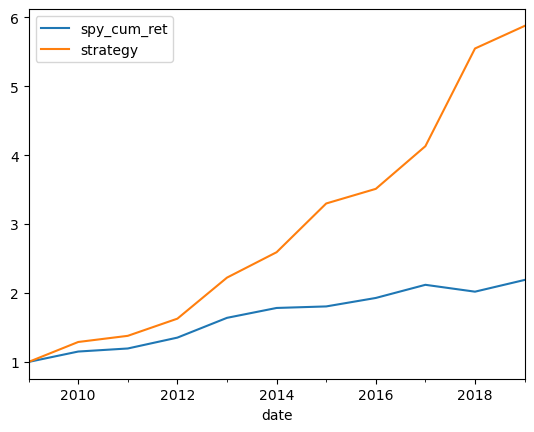

In [494]:
SPY_y.plot();
plt.show()

In [495]:
strategy_mean_ret = (SPY_y['strategy'] - 1).diff().mean()
strategy_std = (SPY_y['strategy'] - 1).diff().std()
print('Strategy Sharpe Ratio: ',strategy_mean_ret/strategy_std)

Strategy Sharpe Ratio:  1.2769885364441027


In [496]:
print(strategy_mean_ret)
print(strategy_std)

0.4875446129716621
0.3817924742921161


In [553]:
spy_mean_ret = (SPY_y['spy_cum_ret'] - 1).diff().mean()
spy_std = (SPY_y['spy_cum_ret'] - 1).diff().std()
print('SPY Sharpe Ratio: ',spy_mean_ret/spy_std)

SPY Sharpe Ratio:  1.1186285109898235


In [554]:
print(spy_mean_ret)
print(spy_std)

0.11894259999999983
0.10632895445759105


### Total Returns

In [500]:
SPY_y['strategy'].iloc[-1]

np.float64(5.875446129716621)

In [501]:
SPY_y['spy_cum_ret'].iloc[-1]

np.float64(2.1894259999999983)

### Computing the $\alpha$ of the strategy

In [502]:
strategy_ret = (SPY_y['strategy'] - 1).diff().values[1:]
spy_ret = (SPY_y['spy_cum_ret'] - 1).diff().values[1:]

In [503]:
beta = (np.cov(spy_ret,strategy_ret)/np.var(spy_ret))[1,0]
beta

np.float64(-2.1277238264839706)

In [504]:
residual_ret = strategy_ret - beta * spy_ret

In [505]:
residual_ret

array([0.6096808 , 0.18383423, 0.5849782 , 1.20575447, 0.6736068 ,
       0.75455108, 0.47364344, 1.02521806, 1.20544766, 0.68950143])

In [506]:
alpha = np.mean(residual_ret)
alpha

np.float64(0.740621616975614)

In [507]:
IR = np.mean(residual_ret)/np.std(residual_ret)
IR

np.float64(2.41132897867218)

In [508]:
from scipy.stats import linregress

In [546]:
result = linregress(spy_ret,strategy_ret)

In [547]:
beta = result.slope
print(beta)

-1.914951443835572


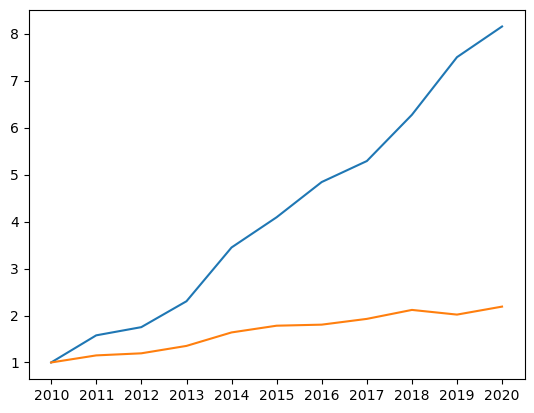

In [555]:
plt.plot(SPY_y['strategy'] - beta * SPY_y['spy_cum_ret'] + beta);
plt.plot(SPY_y['spy_cum_ret']);
# plt.plot(['spy_cum_ret'])

In [511]:
alpha = result.intercept
print(alpha)

0.7153139165752189


In [512]:
residuals = strategy_ret - (alpha + beta*spy_ret)
print(residuals)

[-0.13768217 -0.54092253 -0.16390631  0.42940595 -0.07221038  0.0344951
 -0.26780701  0.26931271  0.5113229  -0.06200826]


In [513]:
np.mean(residuals)

np.float64(-2.7755575615628914e-17)

In [514]:
np.std(residuals)

np.float64(0.3063916799314686)

In [515]:
from scipy.stats import norm

In [516]:
x = np.linspace(-0.4,0.4,30)

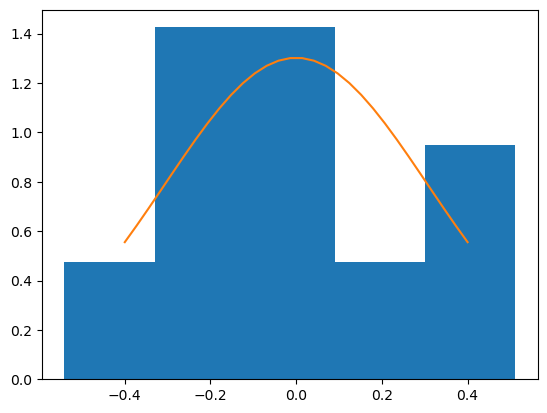

In [517]:
plt.hist(residuals,bins=5,density=True)[1]
plt.plot(x,norm(loc = 0.0,scale=np.std(residuals)).pdf(x));

In [559]:
hedged_portfolio = SPY_y['strategy'] - beta*SPY_y['spy_cum_ret']+beta

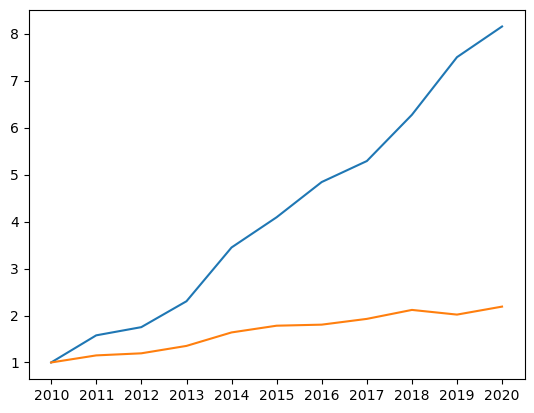

In [562]:
plt.plot(hedged_portfolio);
plt.plot(SPY_y['spy_cum_ret'])

In [521]:
hedged_ret = (hedged_portfolio).diff().values[1:]
spy_ret = (SPY_y['spy_cum_ret'] -a*SPY_y['strategy'].iloc[0]).diff().values[1:]

In [522]:
result = linregress(spy_ret,hedged_ret)

In [523]:
result.slope

np.float64(1.449921222806476e-15)

In [524]:
result.intercept

np.float64(0.7153139165752187)

In [525]:
np.std(hedged_ret)

np.float64(0.3063916799314687)

In [526]:
np.mean(hedged_ret)

np.float64(0.7153139165752189)

In [528]:
SR_hedge = np.mean(hedged_ret)/np.std(hedged_ret)

In [529]:
SR_hedge

np.float64(2.33463884115657)

In [564]:
hedged_portfolio.iloc[-1]

np.float64(8.153139165752188)